<a href="https://colab.research.google.com/github/nangulo2132/ML-Final-Project/blob/main/OD_Graph_and_Baseline_for_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric
import zipfile, os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print("All imports OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.4 MB/s eta 0:00:00
All imports OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
CBG_ZIP_PATH    = "/content/drive/My Drive/Colab Notebooks/tl_2022_36_bg.zip"
LODES_OD_PATH   = "/content/drive/My Drive/Colab Notebooks/ny_od_main_JT00_2022.csv.gz"
GTFS_STOPS_PATH = "/content/drive/My Drive/Colab Notebooks/stops.txt"

#drop Staten Island (085)
NYC_COUNTY_FIPS = ['36005', '36047', '36061', '36081']  # Bronx, Brooklyn, Manhattan, Queens

MIN_OD_FLOW = 5

#extract the shapefile
CBG_EXTRACT_DIR = "/content/cbg_shapefile/"

In [ ]:

with zipfile.ZipFile(CBG_ZIP_PATH, 'r') as z:
    z.extractall(CBG_EXTRACT_DIR)
print("Extracted:", os.listdir(CBG_EXTRACT_DIR))

#Load and filter to NYC (no Staten Island)
gdf = gpd.read_file(CBG_EXTRACT_DIR + "tl_2022_36_bg.shp")
gdf['STATEFP_COUNTYFP'] = gdf['STATEFP'] + gdf['COUNTYFP']
nyc_cbg = gdf[gdf['STATEFP_COUNTYFP'].isin(NYC_COUNTY_FIPS)].copy()
nyc_cbg = nyc_cbg.to_crs(epsg=4326)

#Centroids
nyc_cbg['centroid_lon'] = nyc_cbg.geometry.centroid.x
nyc_cbg['centroid_lat'] = nyc_cbg.geometry.centroid.y

#Node IDs and borough labels
nyc_cbg = nyc_cbg.reset_index(drop=True)
nyc_cbg['node_id'] = nyc_cbg.index
countyfp_to_borough = {'005': 'Bronx', '047': 'Brooklyn', '061': 'Manhattan', '081': 'Queens'}
nyc_cbg['borough'] = nyc_cbg['COUNTYFP'].map(countyfp_to_borough)

#Lookup dict for edge building
geoid_to_node = dict(zip(nyc_cbg['GEOID'], nyc_cbg['node_id']))

print(f"Nodes: {len(nyc_cbg):,} census block groups")
print(nyc_cbg['borough'].value_counts())

Extracted: ['tl_2022_36_bg.dbf', 'tl_2022_36_bg.shp.ea.iso.xml', 'tl_2022_36_bg.prj', 'tl_2022_36_bg.shx', 'tl_2022_36_bg.shp', 'tl_2022_36_bg.shp.iso.xml', 'tl_2022_36_bg.cpg']


/tmp/ipykernel_1057/3363971350.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nyc_cbg['centroid_lon'] = nyc_cbg.geometry.centroid.x
/tmp/ipykernel_1057/3363971350.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nyc_cbg['centroid_lat'] = nyc_cbg.geometry.centroid.y


Nodes: 6,433 census block groups
borough
Brooklyn     2156
Queens       1803
Manhattan    1292
Bronx        1182
Name: count, dtype: int64


In [ ]:
#Load GTFS stops
stops = pd.read_csv(GTFS_STOPS_PATH)[['stop_id', 'stop_lat', 'stop_lon']].dropna()
stops_gdf = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(stops.stop_lon, stops.stop_lat),
    crs ='EPSG:4326'
)

PROJECTED_CRS = 'EPSG:2263'
stops_proj = stops_gdf.to_crs(PROJECTED_CRS)
cbg_proj = nyc_cbg.to_crs(PROJECTED_CRS)

cbg_proj['radius_m'] = 800

cbg_proj['centroid'] = cbg_proj.geometry.centroid
cbg_proj['geometry_buffered'] = cbg_proj['centroid'].buffer(cbg_proj['radius_m'])

cbg_buffered = cbg_proj.set_geometry('geometry_buffered')[['node_id', 'geometry_buffered']]

joined = gpd.sjoin(stops_proj, cbg_buffered[['node_id', 'geometry_buffered']], how='left', predicate='within')
stop_counts = joined.groupby('node_id').size().reset_index(name='stop_count')

cbg_proj = cbg_proj.drop(
    columns=[col for col in cbg_proj.columns if 'stop_count' in col],
    errors='ignore'
)

cbg_proj = cbg_proj.merge(stop_counts, on='node_id', how='left')
cbg_proj['stop_count'] = cbg_proj['stop_count'].fillna(0)

transit_deserts = (cbg_proj['stop_count'] == 0).sum()
print(f"Stop count range: {cbg_proj['stop_count'].min():.0f} – {cbg_proj['stop_count'].max():.0f}")
print(f"Transit deserts (0 stops): {transit_deserts} of {len(cbg_proj)} CBGs ({100*transit_deserts/len(cbg_proj):.1f}%)")
cbg_proj[['node_id', 'borough', 'stop_count']].groupby('borough').mean().round(2)

Stop count range: 0 – 15
Transit deserts (0 stops): 5071 of 6433 CBGs (78.8%)


,node_id,stop_count
borough,,
Bronx,3169.94,0.65
Brooklyn,3263.26,0.70
Manhattan,2688.78,1.48
Queens,3567.48,0.30


In [ ]:
#pandas reads .gz natively
lodes = pd.read_csv(LODES_OD_PATH, dtype={'w_geocode': str, 'h_geocode': str})
print(f"Raw LODES rows: {len(lodes):,}")

#census block to block group (first 12 digits of geocode)
lodes['origin_cbg'] = lodes['h_geocode'].str[:12]
lodes['dest_cbg']   = lodes['w_geocode'].str[:12]

od_cbg = (
    lodes.groupby(['origin_cbg', 'dest_cbg'])['S000']
    .sum()
    .reset_index()
    .rename(columns={'S000': 'demand'})
)

#Keep only NYC CBGs, drop low-volume pairs
valid_geoids = set(nyc_cbg['GEOID'])
od_cbg = od_cbg[
    od_cbg['origin_cbg'].isin(valid_geoids) &
    od_cbg['dest_cbg'].isin(valid_geoids) &
    (od_cbg['origin_cbg'] != od_cbg['dest_cbg']) &
    (od_cbg['demand'] >= MIN_OD_FLOW)
].copy()

#Map to integer node IDs
od_cbg['src'] = od_cbg['origin_cbg'].map(geoid_to_node)
od_cbg['dst'] = od_cbg['dest_cbg'].map(geoid_to_node)
od_cbg = od_cbg.dropna(subset=['src', 'dst'])
od_cbg[['src', 'dst']] = od_cbg[['src', 'dst']].astype(int)
od_cbg = od_cbg.reset_index(drop=True)

print(f"OD edges after filtering: {len(od_cbg):,}")
print(f"Demand range: {od_cbg['demand'].min()} – {od_cbg['demand'].max()}")

Raw LODES rows: 7,576,777
OD edges after filtering: 79,928
Demand range: 5 – 377


In [ ]:
print("Stop count stats:")
print(cbg_proj['stop_count'].describe())

print("\nDemand stats:")
print(od_cbg['demand'].describe())

Stop count stats:
count    6433.000000
mean        0.735893
std         1.565242
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        15.000000
Name: stop_count, dtype: float64

Demand stats:
count    79928.000000
mean         7.978318
std          5.634047
min          5.000000
25%          5.000000
50%          6.000000
75%          9.000000
max        377.000000
Name: demand, dtype: float64


In [ ]:
#Map stop counts onto edges
node_to_stops = dict(zip(cbg_proj['node_id'], cbg_proj['stop_count']))
od_cbg['src_stop_count'] = od_cbg['src'].map(node_to_stops)
od_cbg['dst_stop_count'] = od_cbg['dst'].map(node_to_stops)

#Underserved = high demand AND low transit access at both endpoints
demand_thresh = 6
stop_thresh   = 1

od_cbg['is_underserved'] = (
    (od_cbg['demand'] >= demand_thresh) &
    (od_cbg['src_stop_count'] <= stop_thresh) &
    (od_cbg['dst_stop_count'] <= stop_thresh)
).astype(int)

print(f"Edges above demand threshold: {(od_cbg['demand'] >= demand_thresh).sum():,} ({100*(od_cbg['demand'] >= demand_thresh).mean():.1f}%)")
print(f"Edges with stop deficit:      {((od_cbg['src_stop_count'] < stop_thresh) | (od_cbg['dst_stop_count'] < stop_thresh)).sum():,}")
print(f"\nTotal edges:           {len(od_cbg):,}")
print(f"Underserved corridors: {od_cbg['is_underserved'].sum():,} ({100*od_cbg['is_underserved'].mean():.1f}%)")
print(f"Well-served corridors: {(od_cbg['is_underserved']==0).sum():,}")

Edges above demand threshold: 54,353 (68.0%)
Edges with stop deficit:      64,449

Total edges:           79,928
Underserved corridors: 13,123 (16.4%)
Well-served corridors: 66,805


In [ ]:
#Demand-rank Baseline

In [ ]:
#Baseline: flag the top X% of edges by demand as underserved
#where X matches the actual label prevalence
threshold = od_cbg['is_underserved'].mean()

od_cbg['demand_rank_pct'] = od_cbg['demand'].rank(pct=True)
od_cbg['baseline_pred']   = (od_cbg['demand_rank_pct'] > (1 - threshold)).astype(int)

print("=== Demand-Rank Baseline ===")
print(classification_report(
    od_cbg['is_underserved'],
    od_cbg['baseline_pred'],
    target_names=['well-served', 'underserved']
))
print("This is the score GNN needs to beat.")

=== Demand-Rank Baseline ===
              precision    recall  f1-score   support

 well-served       0.84      0.85      0.84     66805
 underserved       0.19      0.18      0.19     13123

    accuracy                           0.74     79928
   macro avg       0.52      0.51      0.52     79928
weighted avg       0.73      0.74      0.74     79928

This is the score GNN needs to beat.


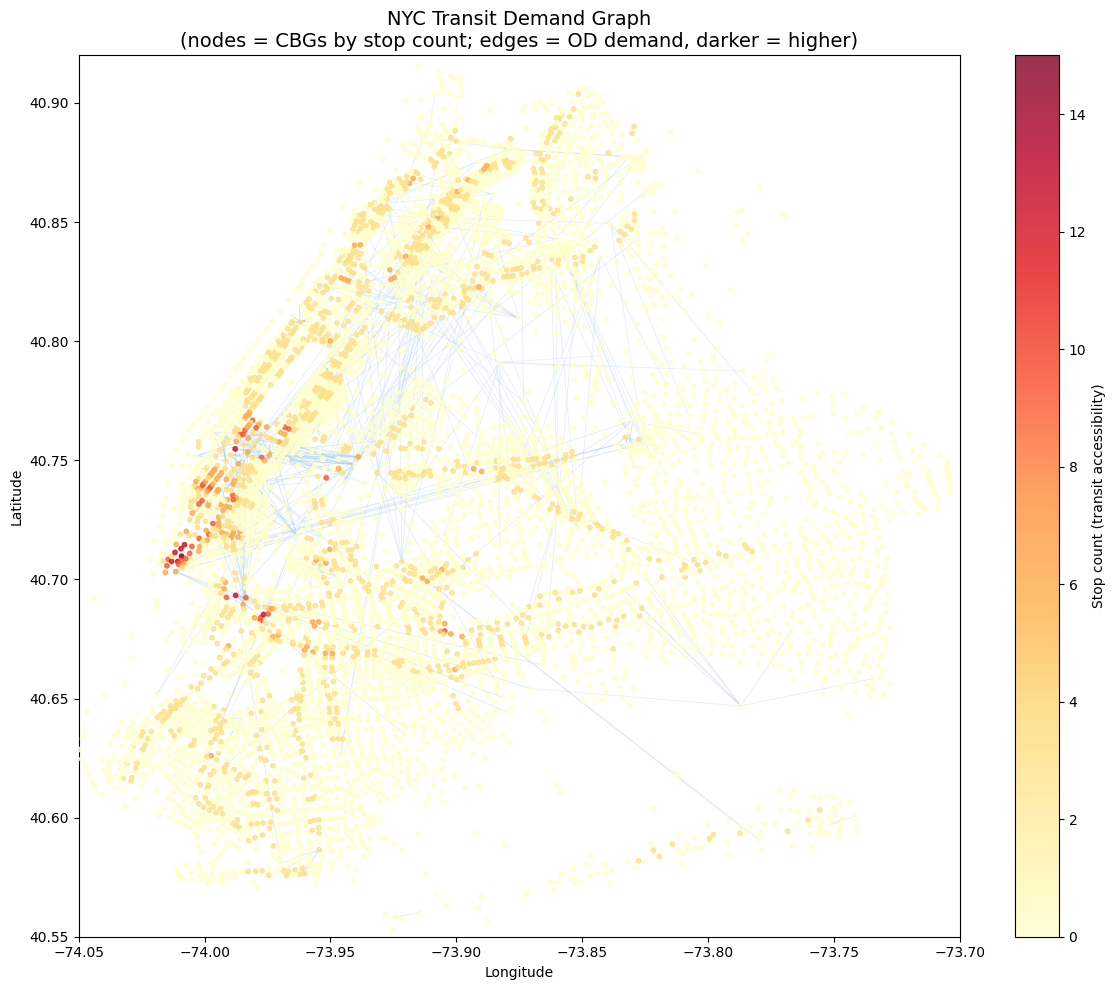

Plotted 367 edges


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

#Nodes colored by stop count
scatter = ax.scatter(
    nyc_cbg['centroid_lon'],
    nyc_cbg['centroid_lat'],
    c=cbg_proj['stop_count'],
    cmap='YlOrRd',
    s=10, alpha=0.8, zorder=3
)
plt.colorbar(scatter, ax=ax, label='Stop count (transit accessibility)')

#Attach borough to edges for balanced sampling
node_to_borough = dict(zip(nyc_cbg['node_id'], nyc_cbg['borough']))
od_cbg['src_borough'] = od_cbg['src'].map(node_to_borough)
od_cbg['dst_borough'] = od_cbg['dst'].map(node_to_borough)

#Sample edges per borough-pair
edges_list = []
for name, group in od_cbg.groupby(['src_borough', 'dst_borough']):
    edges_list.append(group.nlargest(min(80, len(group)), 'demand'))
top_edges = pd.concat(edges_list).drop_duplicates()

#Per-node cap so no single hub dominates
MAX_EDGES_PER_NODE = 8
src_counts, dst_counts, filtered_rows = {}, {}, []
for _, row in top_edges.sort_values('demand', ascending=False).iterrows():
    s, d = int(row['src']), int(row['dst'])
    if src_counts.get(s, 0) < MAX_EDGES_PER_NODE and dst_counts.get(d, 0) < MAX_EDGES_PER_NODE:
        filtered_rows.append(row)
        src_counts[s] = src_counts.get(s, 0) + 1
        dst_counts[d] = dst_counts.get(d, 0) + 1
top_edges = pd.DataFrame(filtered_rows)

#Color edges by demand
demand_vals = top_edges['demand'].values
demand_norm = (demand_vals - demand_vals.min()) / (demand_vals.max() - demand_vals.min() + 1e-9)
edge_cmap = plt.cm.Blues

for i, (_, row) in enumerate(top_edges.iterrows()):
    src_node = nyc_cbg[nyc_cbg['node_id'] == row['src']].iloc[0]
    dst_node = nyc_cbg[nyc_cbg['node_id'] == row['dst']].iloc[0]
    color = edge_cmap(0.3 + 0.7 * demand_norm[i])
    ax.plot(
        [src_node['centroid_lon'], dst_node['centroid_lon']],
        [src_node['centroid_lat'], dst_node['centroid_lat']],
        color=color, alpha=0.35, linewidth=0.6, zorder=1
    )

ax.set_xlim(-74.05, -73.70)
ax.set_ylim(40.55, 40.92)
ax.set_title('NYC Transit Demand Graph\n(nodes = CBGs by stop count; edges = OD demand, darker = higher)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('demand_graph.png', dpi=150)
plt.show()
print(f"Plotted {len(top_edges)} edges")

/tmp/ipykernel_1057/629375370.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(color)
/tmp/ipykernel_1057/629375370.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(color)


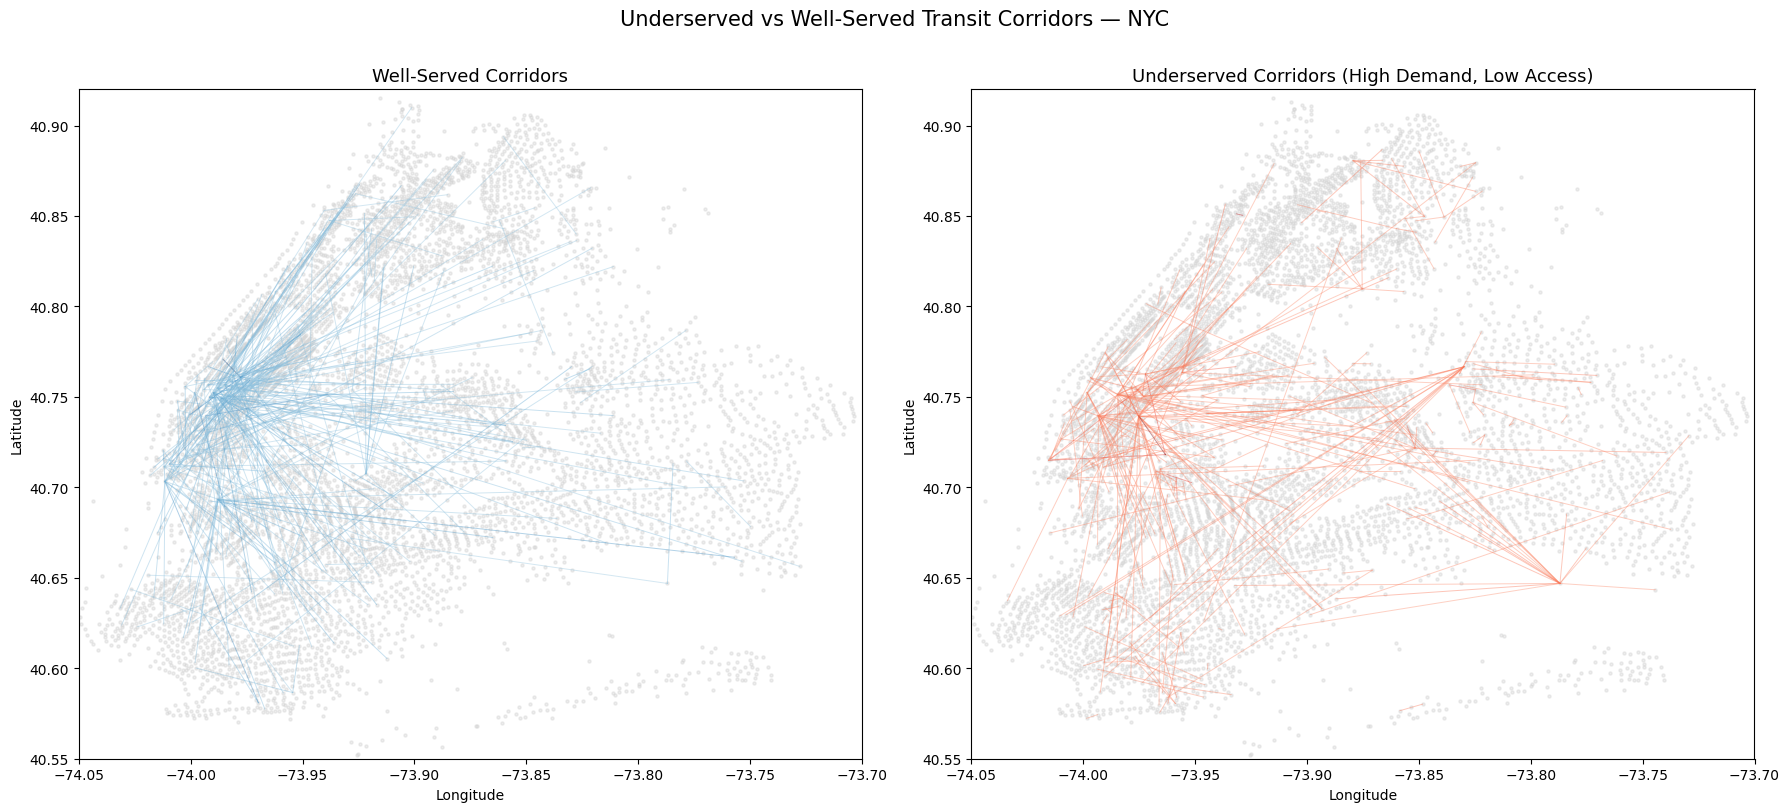

Saved underserved_corridors.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, label, title, color in [
    (axes[0], 0, 'Well-Served Corridors', 'Blues'),
    (axes[1], 1, 'Underserved Corridors (High Demand, Low Access)', 'Reds')
]:
    subset = od_cbg[od_cbg['is_underserved'] == label]

    ax.scatter(
        nyc_cbg['centroid_lon'], nyc_cbg['centroid_lat'],
        c='lightgray', s=5, alpha=0.4, zorder=2
    )

    #Sample edges
    sample = subset.sample(n=min(300, len(subset)), random_state=42)
    d_vals = sample['demand'].values
    d_norm = (d_vals - d_vals.min()) / (d_vals.max() - d_vals.min() + 1e-9)
    cmap = plt.cm.get_cmap(color)

    for i, (_, row) in enumerate(sample.iterrows()):
        src_node = nyc_cbg[nyc_cbg['node_id'] == row['src']].iloc[0]
        dst_node = nyc_cbg[nyc_cbg['node_id'] == row['dst']].iloc[0]
        ax.plot(
            [src_node['centroid_lon'], dst_node['centroid_lon']],
            [src_node['centroid_lat'], dst_node['centroid_lat']],
            color=cmap(0.4 + 0.6 * d_norm[i]), alpha=0.4, linewidth=0.7, zorder=3
        )

    ax.set_xlim(-74.05, -73.70)
    ax.set_ylim(40.55, 40.92)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Underserved vs Well-Served Transit Corridors — NYC', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('underserved_corridors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved underserved_corridors.png")